# RESPONSI MODUL 2 - F1D02410122_MOH. SAQIF DENDI AL FAYYED
-----------------------------------------------------------------

##  Import Library

Bagian ini mengimpor tiga library utama yang digunakan sepanjang notebook:

- **`numpy`** — untuk operasi array dan komputasi numerik pada data piksel
- **`matplotlib.pyplot`** — untuk menampilkan gambar dan grafik histogram
- **`cv2` (OpenCV)** — untuk membaca gambar dan konversi ruang warna (BGR ↔ RGB, RGB ↔ Grayscale)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

## Membaca Gambar Background.png & Memisahkan Channel RGB

Gambar background dibaca menggunakan `plt.imread()` lalu dikonversi dari BGR ke RGB menggunakan `cv.cvtColor()`.

Channel warna dipisah menggunakan indexing array NumPy:
- `[:, :, 0]` → channel **Red**
- `[:, :, 1]` → channel **Green**
- `[:, :, 2]` → channel **Blue**

Keempat gambar (R, G, B, dan asli) ditampilkan berdampingan menggunakan `plt.subplots(1, 4)` dengan colormap masing-masing channel.

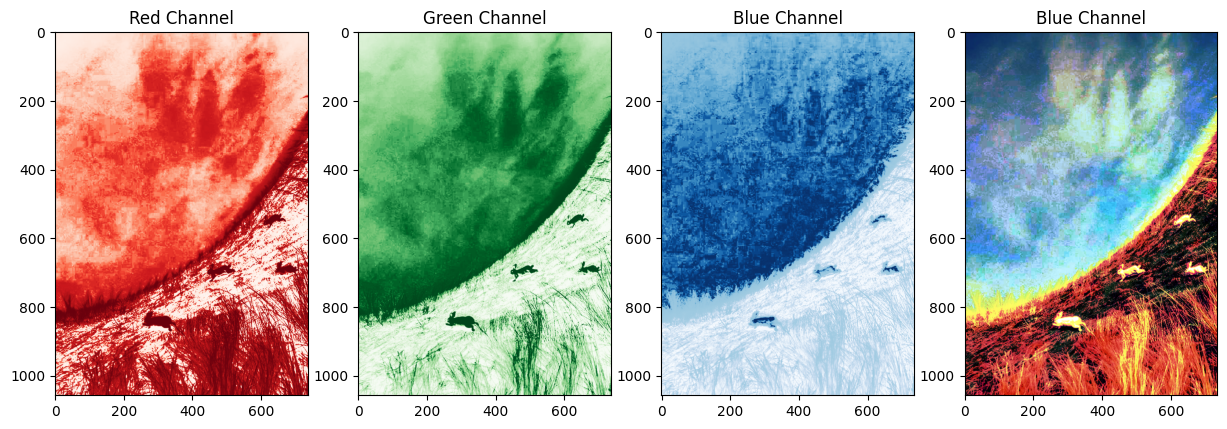

In [ ]:
# Membaca gambar (sudah dalam format RGB)
background = plt.imread('Assets/background.png')
background = cv.cvtColor(background,cv.COLOR_BGR2RGB)


# Memisahkan channel menggunakan indexing [baris, kolom, channel]
red  = background[:, :, 0]
green = background[:, :, 1]
blue = background[:, :, 2]

# Menampilkan hasil
fig, axs = plt.subplots(1, 4, figsize=(15, 5))

axs[0].imshow(red, cmap = "Reds")
axs[0].set_title('Red Channel')

axs[1].imshow(green, cmap = "Greens")
axs[1].set_title('Green Channel')

axs[2].imshow(blue, cmap = "Blues")
axs[2].set_title('Blue Channel')

axs[3].imshow(background, cmap = "gray")
axs[3].set_title('Blue Channel')

plt.show()

## Fungsi untuk menghitung intesitas piksel

Fungsi ini menghitung histogram intensitas piksel secara manual tanpa fungsi bawaan:

1. Gambar dikonversi ke array NumPy
2. Jika gambar berwarna (3D), dirata-ratakan ke grayscale dengan `np.mean(axis=2)`
3. Jika nilai piksel dalam rentang `[0, 1]`, dinormalisasi ke `[0, 255]`
4. Piksel diratakan (flatten) menjadi 1D lalu dihitung frekuensinya ke dalam array `histogram` berukuran 256

Output: list berisi jumlah kemunculan setiap nilai intensitas (0–255)

In [ ]:
def hitung_histogram(gambar):
    img_arr = np.array(gambar)
    
    if len(img_arr.shape) == 3:
        img_arr = np.mean(img_arr, axis=2)
    if img_arr.max() <= 1.1:
        img_arr = img_arr * 255
        
    piksel_flat = img_arr.flatten().astype(int)
    
    histogram = [0] * 256
    for p in piksel_flat:
        if 0 <= p <= 255:
            histogram[p] += 1
    return histogram


## Menampilkan Histogram Channel Background

Fungsi `hitung_histogram()` dipanggil untuk setiap channel (R, G, B) pada gambar background.

Masing-masing histogram ditampilkan sebagai **bar chart** menggunakan fungsi `plt.bar()` dengan warna yang sesuai channelnya. Sumbu X adalah nilai intensitas (0–255) dan sumbu Y adalah jumlah piksel pada tiap nilai intensitas tersebut.

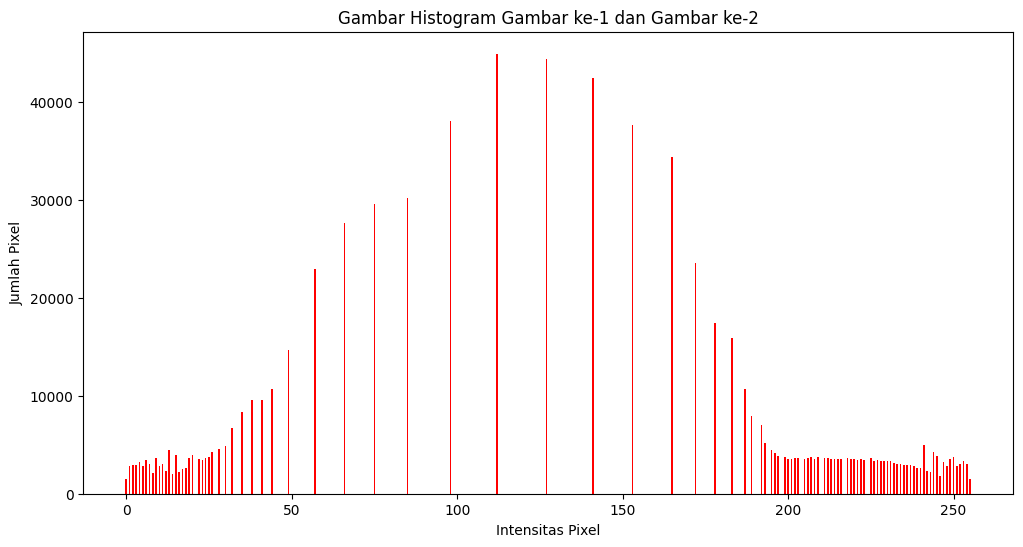

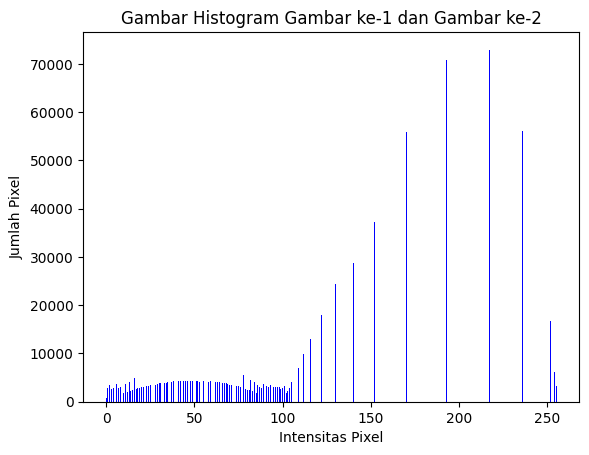

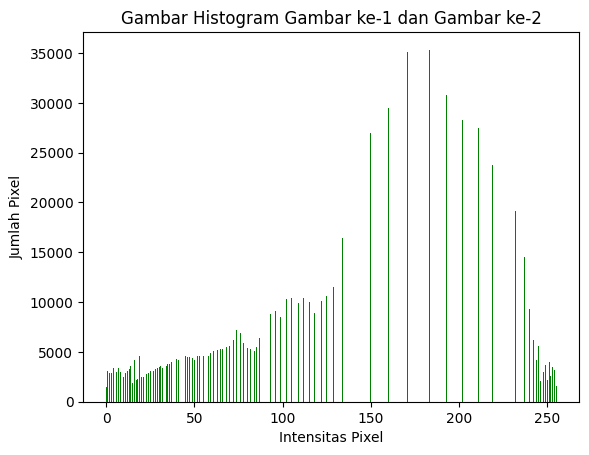

In [ ]:
red_histo = hitung_histogram(red)
blue_histo = hitung_histogram(blue)
green_histo = hitung_histogram(green)

plt.figure(figsize=(12, 6))

plt.bar(range(256), red_histo, width=0.5, color='red') # sebelum di tambahkan atribut
plt.title('Gambar Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.show()

plt.bar(range(256), blue_histo, width=0.5, color='blue') # setelah di tambahkan atribut
plt.title('Gambar Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.show()

plt.bar(range(256), green_histo, width=0.5, color='green') # setelah di tambahkan atribut
plt.title('Gambar Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.show()

## Membaca Gambar Target 

Tiga gambar target dibaca untuk masing-masing channel: `red_target.png`, `green_target.png`, dan `blue_target.png`.

Gambar-gambar ini akan digunakan sebagai **referensi distribusi** dalam proses spesifikasi histogram. Ditampilkan dalam subplot 3×3 menggunakan colormap yang sesuai.

(np.float64(-0.5), np.float64(735.5), np.float64(1057.5), np.float64(-0.5))

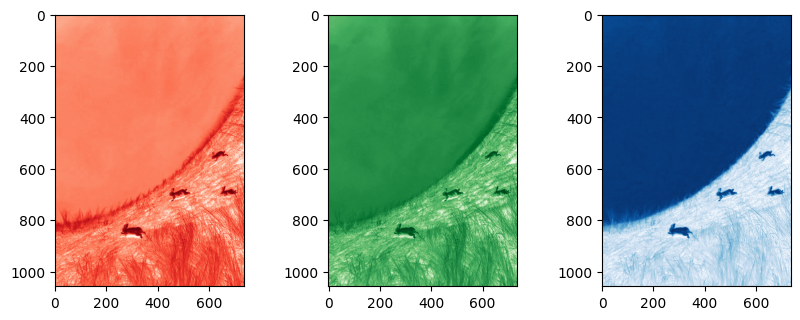

In [ ]:
r_target = plt.imread('Assets/red_target.png')
g_target = plt.imread('Assets/green_target.png')
b_target = plt.imread('Assets/blue_target.png')

plt.figure(figsize=(10,12))
plt.subplot(3, 3, 1)
plt.imshow(r_target, cmap='Reds')
plt.axis('on')

plt.subplot(3, 3, 2)
plt.imshow(g_target, cmap='Greens')
plt.axis('on')

plt.subplot(3, 3, 3)
plt.imshow(b_target, cmap='Blues')
plt.axis('on')

## Hitung Intensitas Piksel Gambar Target

Sama seperti sebelumnya, histogram dihitung untuk setiap channel target (R, G, B) dan ditampilkan satu per satu dengan `plt.bar()`.

Histogram ini mencerminkan distribusi intensitas dari gambar referensi yang akan dicocokkan ke gambar sumber dalam proses spesifikasi histogram.

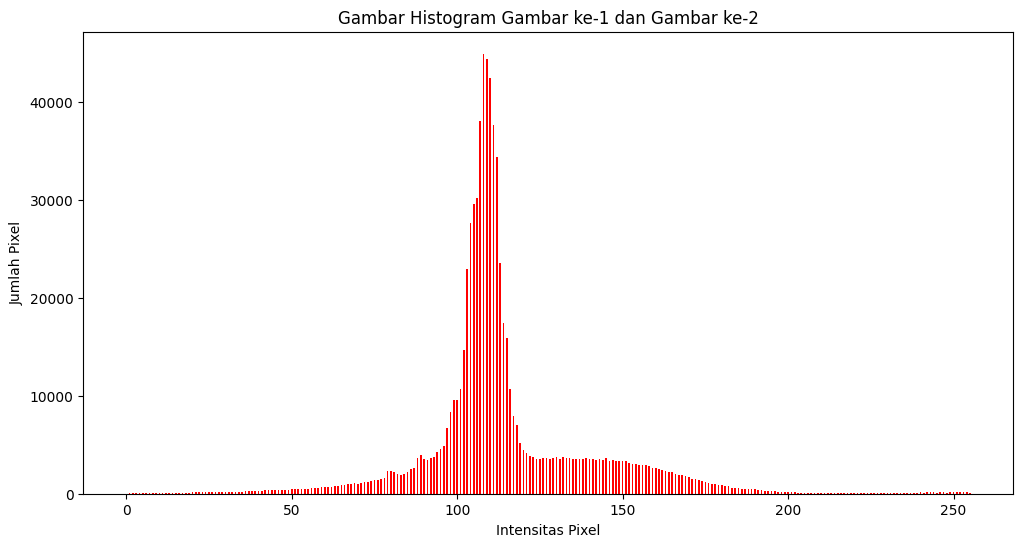

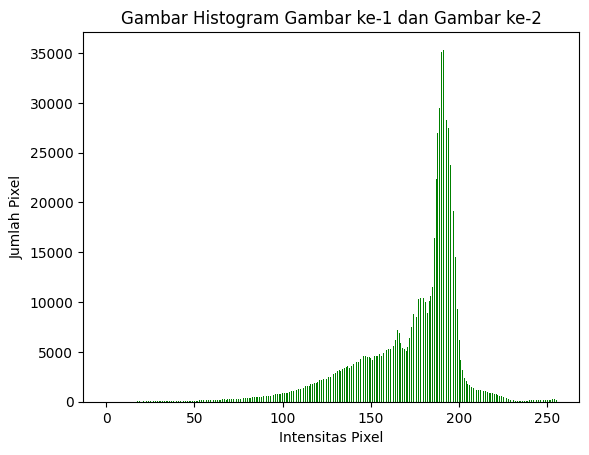

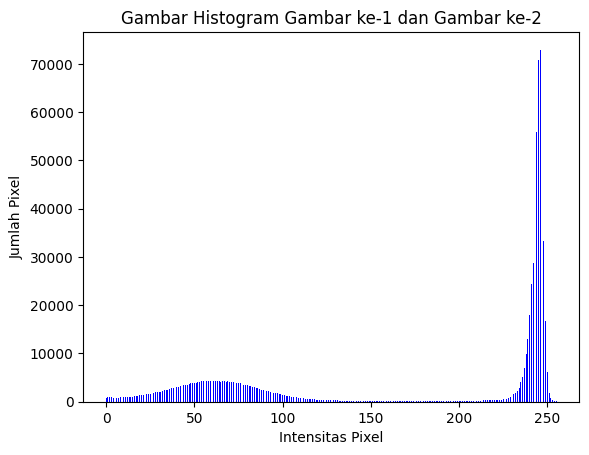

In [ ]:
rht = hitung_histogram(r_target)
bht = hitung_histogram(b_target)
ght = hitung_histogram(g_target)

plt.figure(figsize=(12, 6))

plt.bar(range(256), rht, width=0.5, color='red') # sebelum di tambahkan atribut
plt.title('Gambar Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.show()

plt.bar(range(256), ght, width=0.5, color='green') # setelah di tambahkan atribut
plt.title('Gambar Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.show()

plt.bar(range(256), bht, width=0.5, color='blue') # setelah di tambahkan atribut
plt.title('Gambar Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.show()



## Fungsi Spesifikasi

Fungsi inti untuk melakukan spesifikasi yaitu mengubah distribusi intensitas citra sumber agar menyerupai distribusi citra target.

Langkah-langkah:
1. Hitung histogram citra sumber dan target secara manual (loop piksel)
2. Hitung **CDF (Cumulative Distribution Function)** untuk keduanya
3. Normalisasi CDF ke rentang `[0, 1]`
4. **Pemetaan:** untuk setiap nilai intensitas di sumber, cari nilai terdekat di CDF target (`np.argmin`)
5. Terapkan pemetaan ke seluruh piksel citra sumber

Output: citra hasil dengan distribusi intensitas yang mendekati citra target.

In [ ]:
def spesifikasi_histogram(citra_sumber, citra_target):

    panjang_sumber, lebar_sumber = citra_sumber.shape
    panjang_target, lebar_target = citra_target.shape

    # Hitung histogram citra sumber & target
    histogram_sumber = np.zeros(256, dtype=int)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            histogram_sumber[nilai] += 1

    histogram_target = np.zeros(256, dtype=int)
    for i in range(panjang_target):
        for j in range(lebar_target):
            nilai = citra_target[i, j]
            histogram_target[nilai] += 1

    # Hitung CDF citra sumber & target
    cdf_sumber = np.zeros(256, dtype=int)
    for i in range(256):
        cdf_sumber[i] = np.sum(histogram_sumber[:i+1])

    cdf_sumber_min = cdf_sumber[cdf_sumber > 0].min() if np.any(cdf_sumber > 0) else 0
    cdf_sumber_norm = (cdf_sumber - cdf_sumber_min) / (panjang_sumber * lebar_sumber - cdf_sumber_min)

    cdf_target = np.zeros(256, dtype=int)
    for i in range(256):
        cdf_target[i] = np.sum(histogram_target[:i+1])

    cdf_target_min = cdf_target[cdf_target > 0].min() if np.any(cdf_target > 0) else 0
    cdf_target_norm = (cdf_target - cdf_target_min) / (panjang_target * lebar_target - cdf_target_min)

    # Mencari nilai terdekat
    pemetaan = np.zeros(256, dtype=int)
    for i in range(256):
        idx = np.argmin(np.abs(cdf_target_norm - cdf_sumber_norm[i]))
        pemetaan[i] = idx

    # Terapkan pemetaan ke citra sumber
    hasil = np.zeros_like(citra_sumber)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            hasil[i, j] = pemetaan[nilai]

    return hasil



## Menerapkan Spesifikasi Histogram per Channel

Sebelum diproses, nilai piksel gambar dikonversi dari float `[0,1]` ke integer `[0,255]` menggunakan `.astype(np.uint8)`.

Fungsi `spesifikasi_histogram()` dipanggil terpisah untuk channel Red, Green, dan Blue antara gambar background dan target masing-masing:
- `spesi1` = Red background → Red target
- `spesi2` = Green background → Green target  
- `spesi3` = Blue background → Blue target

Hasil ditampilkan dalam subplot dengan colormap yang sesuai.

(np.float64(-0.5), np.float64(735.5), np.float64(1057.5), np.float64(-0.5))

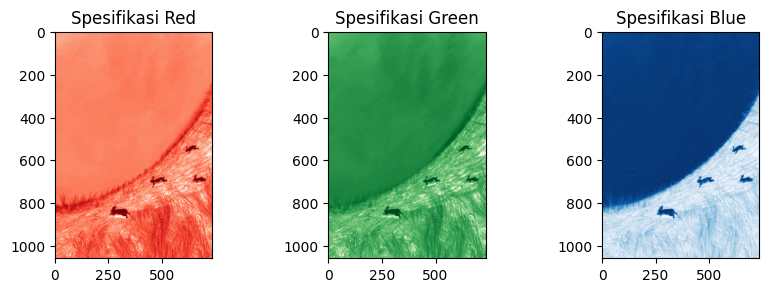

In [ ]:

rt = (r_target * 255).astype(np.uint8)
bt = (b_target * 255).astype(np.uint8)
gt = (g_target * 255).astype(np.uint8)

red = (red * 255).astype(np.uint8)
blue = (blue * 255).astype(np.uint8)
green = (green * 255).astype(np.uint8)

spesi1 = spesifikasi_histogram(red, rt)
spesi2 = spesifikasi_histogram(green, gt)
spesi3 = spesifikasi_histogram(blue, bt)

plt.figure(figsize=(10, 10))
plt.subplot(3, 3, 1)
plt.imshow(spesi1, cmap='Reds')
plt.title("Spesifikasi Red")
plt.axis('on')

plt.subplot(3, 3, 2)
plt.imshow(spesi2, cmap='Greens')
plt.title("Spesifikasi Green")
plt.axis('on')

plt.subplot(3, 3, 3)
plt.imshow(spesi3, cmap='Blues')
plt.title("Spesifikasi Blue")
plt.axis('on')

## Menggabungkan Channel Hasil Spesifikasi

Ketiga channel hasil spesifikasi digabung kembali menjadi satu gambar RGB utuh menggunakan `np.zeros((h,w,3), dtype=np.uint8)`.

Penggabungan dilakukan dengan mengisi setiap channel pada array 3D:
- `gabung[:,:,0]` = spesi1 (Red)
- `gabung[:,:,1]` = spesi2 (Green)
- `gabung[:,:,2]` = spesi3 (Blue)

Hasilnya adalah gambar background yang sudah disesuaikan distribusi warnanya.

(np.float64(-0.5), np.float64(735.5), np.float64(1057.5), np.float64(-0.5))

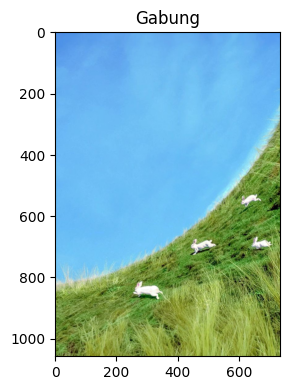

In [ ]:
h, w = spesi1.shape
gabung = np.zeros((h,w,3), dtype=np.uint8)
gabung [:,:,0] = spesi1
gabung [:,:,1] = spesi2
gabung [:,:,2] = spesi3

plt.subplot(1, 2, 1)
plt.imshow(gabung)
plt.title("Gabung")
plt.axis('on')


## Membaca Gambar Foreground (Orang)

Gambar `foreground.png` dibaca menggunakan OpenCV lalu dikonversi dari BGR ke RGB.

Channel R, G, B dipisahkan sama seperti sebelumnya. Gambar asli ditampilkan dengan `plt.imshow()`, diikuti tampilan ketiga channel secara berdampingan menggunakan subplot.

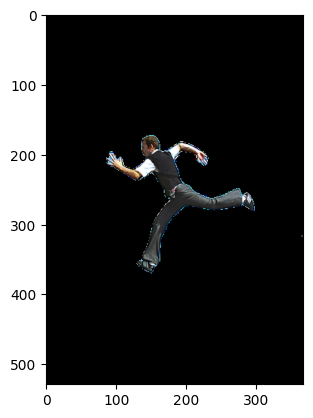

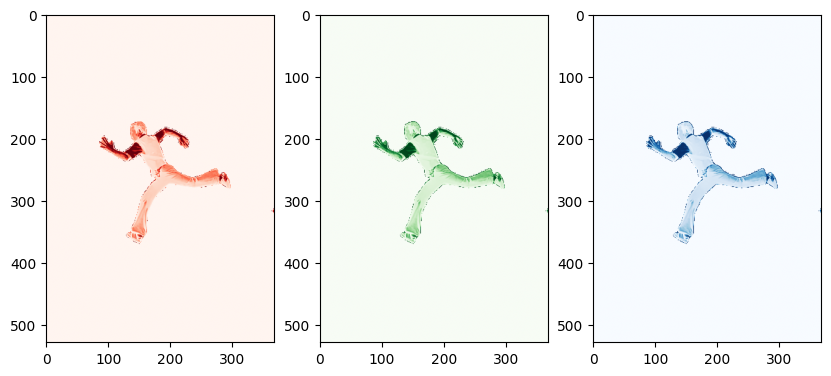

In [ ]:
orang = cv.imread('Assets/foreground.png')
orang = cv.cvtColor(orang,cv.COLOR_BGR2RGB)

o_red = orang[:,:,0]
o_green = orang[:,:,1]
o_blue = orang[:,:,2]

plt.imshow(orang, cmap='gray')
plt.show()
plt.figure(figsize=(10,12))
plt.subplot(1, 3, 1)
plt.imshow(o_red, cmap='Reds')
plt.subplot(1, 3, 2)
plt.imshow(o_green, cmap='Greens')
plt.subplot(1, 3, 3)
plt.imshow(o_blue, cmap='Blues')




## Fungsi Resize Versi Manual
Fungsi ini melakukan resize gambar secara manual.

**Cara kerja:**
- Untuk setiap piksel di gambar output `(i, j)`, hitung koordinat sumber yang bersesuaian dengan rumus:
  - `src_i = int(i * h / target_h)`
  - `src_j = int(j * w / target_w)`
- Salin nilai piksel dari koordinat sumber ke koordinat tujuan

Fungsi mendukung gambar **grayscale** (2D) maupun **RGB** (3D). Digunakan untuk menyamakan ukuran foreground (`1058×736`) agar cocok dengan background.

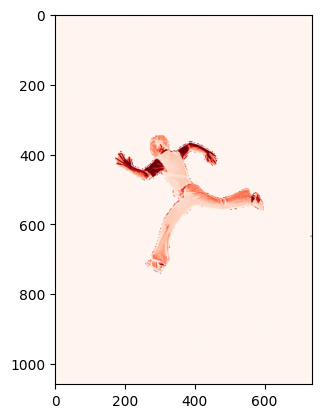

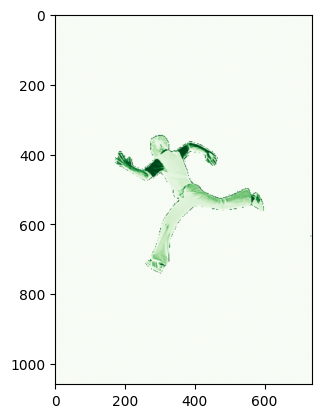

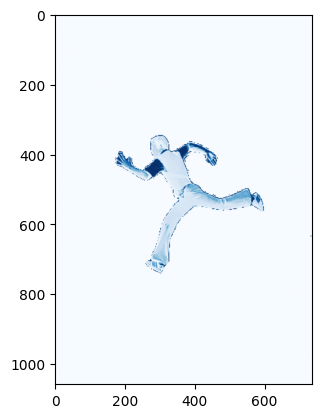

In [ ]:
def besar(image, target_h, target_w):
    if image.ndim == 2:
        # Grayscale
        h, w = image.shape
        hasil = np.zeros((target_h, target_w), dtype=image.dtype)
        for i in range(target_h):
            for j in range(target_w):
                src_i = int(i * h / target_h)
                src_j = int(j * w / target_w)
                hasil[i, j] = image[src_i, src_j]
        return hasil
    else:
        # RGB — proses per channel
        h, w = image.shape[:2]
        hasil = np.zeros((target_h, target_w, 3), dtype=image.dtype)
        for i in range(target_h):
            for j in range(target_w):
                src_i = int(i * h / target_h)
                src_j = int(j * w / target_w)
                hasil[i, j] = image[src_i, src_j]
        return hasil

o_red = besar(o_red,1058,736)
o_green = besar(o_green,1058,736)
o_blue = besar(o_blue,1058,736)

plt.imshow(o_red, cmap="Reds")
plt.show()
plt.imshow(o_green, cmap="Greens")
plt.show()
plt.imshow(o_blue, cmap="Blues")
plt.show()




## Rekonstruksi Gambar Orang ke RGB

Setelah resize, ketiga channel foreground (o_red, o_green, o_blue) digabung kembali menjadi gambar RGB `orang_rgb` berukuran `(h, w, 3)` menggunakan `np.zeros` dan pengisian per channel.

Gambar orang yang sudah direkonstruksi ditampilkan dengan `plt.imshow()`.

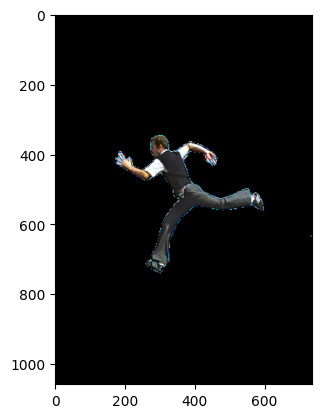

In [ ]:
h,w = spesi1.shape
orang_rgb = np.zeros((h,w,3), dtype=np.uint8)
orang_rgb[:,:,0]= o_red
orang_rgb[:,:,1]= o_green
orang_rgb[:,:,2]= o_blue

plt.imshow(orang_rgb, cmap="gray")
plt.show()

## Fungsi Menumpuk gambar

**`copy(gambar)`:** menyalin gambar grayscale piksel per piksel secara manual (tanpa menggunakan fungsi salin bawaan NumPy).

**`gabungin(citra_depan, citra_belakang)`:** menggabungkan dua gambar RGB dengan logika sederhana:
- Jika **salah satu channel** piksel foreground `> 0` (ada objek), gunakan piksel foreground
- Jika semua channel foreground `== 0` (piksel hitam/kosong), gunakan piksel background

Hasilnya adalah komposit: orang ditampilkan di atas background yang sudah diproses spesifikasi histogram.

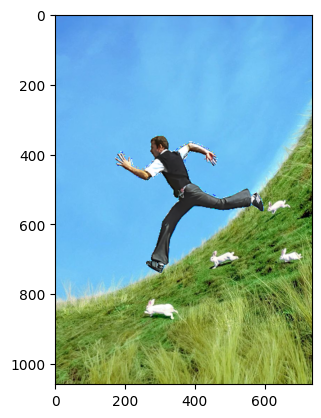

In [ ]:
def copy(gambar):
    h, w = gambar.shape
    hasil = np.zeros((h, w), dtype=gambar.dtype)
    for i in range(h):
        for j in range(w):
            hasil[i][j] = gambar[i][j]
    return hasil

def gabungin(citra_depan, citra_belakang):

    h, w = citra_depan.shape[:2]
    hasil = np.zeros((h, w, 3), dtype=citra_depan.dtype)

    for i in range(h):
        for j in range(w):
            # Cek apakah piksel people > 0 (ada objek) di semua channel
            if citra_depan[i, j, 0] > 0 or citra_depan[i, j, 1] > 0 or citra_depan[i, j, 2] > 0:
                hasil[i, j, 0] = citra_depan[i, j, 0]
                hasil[i, j, 1] = citra_depan[i, j, 1]
                hasil[i, j, 2] = citra_depan[i, j, 2]
            else:
                hasil[i, j, 0] = citra_belakang[i, j, 0]
                hasil[i, j, 1] = citra_belakang[i, j, 1]
                hasil[i, j, 2] = citra_belakang[i, j, 2]

    return hasil

gambar = gabungin(orang_rgb,gabung)

plt.imshow(gambar, cmap="gray")
plt.show()


## Histogram Gambar Gabungan (Grayscale)

Gambar hasil compositing dikonversi ke grayscale menggunakan `cv.cvtColor(gambar, cv.COLOR_RGB2GRAY)`.

Histogram grayscale dihitung dan ditampilkan untuk melihat distribusi intensitas keseluruhan gambar hasil gabungan. Gambar grayscale juga ditampilkan dengan `plt.imshow(ireng, cmap='gray')`.

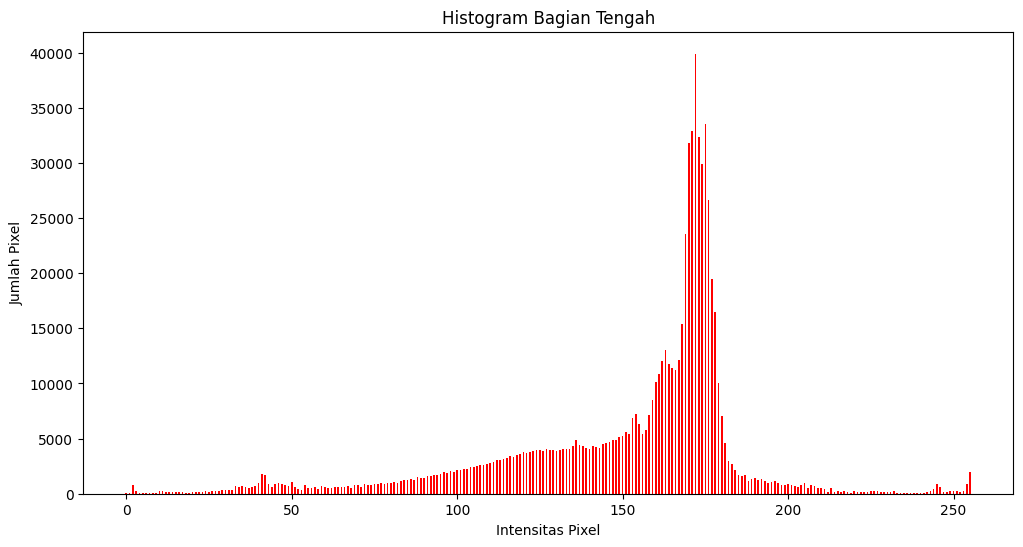

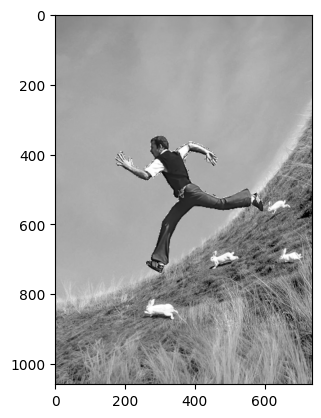

In [ ]:
ireng = cv.cvtColor(gambar,cv.COLOR_RGB2GRAY)
gray_histo = hitung_histogram(ireng)

plt.figure(figsize=(12, 6))

plt.bar(range(256), gray_histo, width=0.5, color='red') # sebelum di tambahkan atribut
plt.title('Histogram Bagian Tengah')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')
plt.show()

plt.imshow(ireng,cmap='gray')

## Memotong Gambar Menjadi 3 Bagian 

Gambar hasil compositing dipotong secara vertikal menjadi 3 bagian berdasarkan kolom:
- `potong1` = kolom 0 hingga 274 (bagian kiri)
- `potong2` = kolom 275 hingga 459 (bagian tengah)
- `potong3` = kolom 460 hingga akhir (bagian kanan)

Ketiga potongan ditampilkan berdampingan dalam subplot. Pemisahan ini bertujuan untuk memproses hanya bagian tengah gambar dengan ekualisasi histogram.

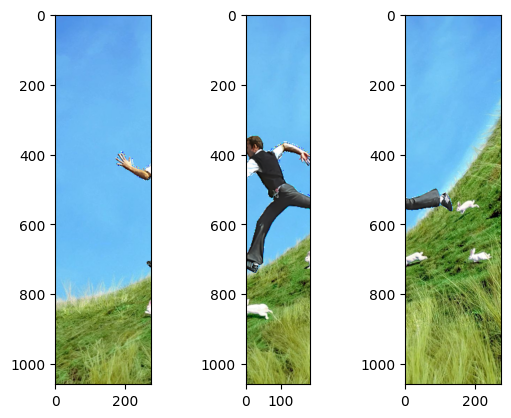

In [ ]:
potong1 = gambar[:,:275]
potong2 = gambar[:,275:460]
potong3 = gambar[:,460:]


plt.subplot(1,3,1)
plt.imshow(potong1,cmap='gray')
plt.subplot(1,3,2)
plt.imshow(potong2,cmap='gray')
plt.subplot(1,3,3)
plt.imshow(potong3,cmap='gray')

## Membuat Histogram untuk Bagian Tengah (Grayscale)

Bagian tengah (`potong2`) dikonversi ke grayscale dan dihitung histogramnya.

Histogram ditampilkan sebagai bar chart merah untuk melihat distribusi intensitas sebelum dilakukan ekualisasi. Ini adalah kondisi awal bagian tengah sebelum diproses lebih lanjut.

Text(0, 0.5, 'Jumlah Pixel')

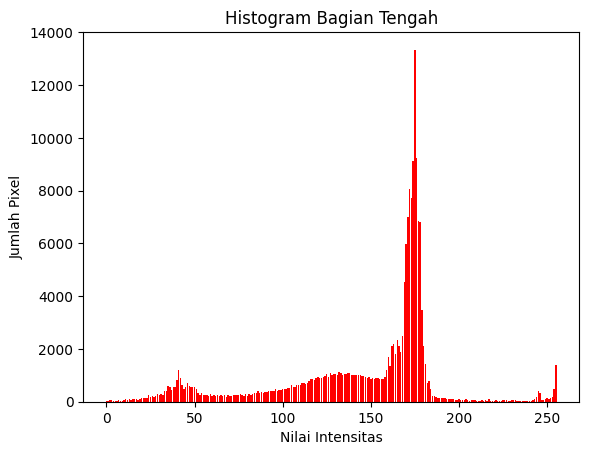

In [ ]:
tengah = potong2
tengah = cv.cvtColor(tengah,cv.COLOR_RGB2GRAY)

tengah_histo = hitung_histogram(tengah)
plt.bar(range(256), tengah_histo, color='red')
plt.title('Histogram Bagian Tengah')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Pixel')

## Memisahkan Channel Bagian Tengah

Bagian tengah dikonversi dari RGB ke BGR (`cv.cvtColor` dengan `COLOR_RGB2BGR`) lalu channel-nya dipisah menjadi `merah`, `hijau`, dan `biru`.


Text(0.5, 1.0, 'Blue Channel')

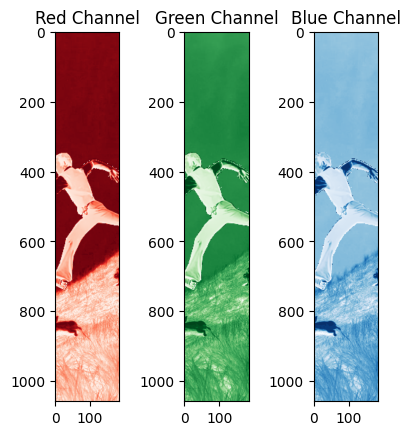

In [ ]:
st = potong2
simpan_tengah = cv.cvtColor(st,cv.COLOR_BGR2RGB)

merah  = simpan_tengah[:, :, 0]
hijau = simpan_tengah[:, :, 1]
biru = simpan_tengah[:, :, 2]

plt.subplot(1, 4, 1)
plt.imshow(merah, cmap = "Reds")
plt.title('Red Channel')

plt.subplot(1, 4, 2)
plt.imshow(hijau, cmap = "Greens")
plt.title('Green Channel')

plt.subplot(1, 4, 3)
plt.imshow(biru, cmap = "Blues")
plt.title('Blue Channel')


## Fungsi Ekualisasi

Fungsi ini untuk melakukan Ekualisasi, yaitu teknik peningkatan kontras dengan meratakan distribusi intensitas piksel.

**Langkah-langkah:**
1. Hitung **histogram** piksel (frekuensi tiap nilai 0–255)
2. Hitung **CDF** (Cumulative Distribution Function) secara kumulatif
3. **Normalisasi CDF** ke rentang [0, 255] dengan rumus:
   ```
   cdf_norm = round((cdf - cdf_min) / (cdf_max - cdf_min) * 255)
   ```
4. Petakan setiap nilai piksel lama ke nilai baru berdasarkan CDF yang dinormalisasi

Output: gambar dengan kontras yang lebih merata dan terdistribusi lebih luas.

In [ ]:
# Fungsi untuk ekualisasi histogram
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_max = cdf[cdf > 0].max() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (cdf_max - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil


## Menerapkan Ekualisasi & Rekonstruksi RGB Tengah

Ekualisasi histogram diterapkan ke setiap channel bagian tengah (`merah`, `hijau`, `biru`) secara terpisah menghasilkan `er`, `eg`, `eb`.

Ketiga channel hasil ekualisasi digabung kembali menjadi `gabungkah` (gambar RGB):
- `gabungkah[:,:,2]` = er
- `gabungkah[:,:,1]` = eg
- `gabungkah[:,:,0]` = eb



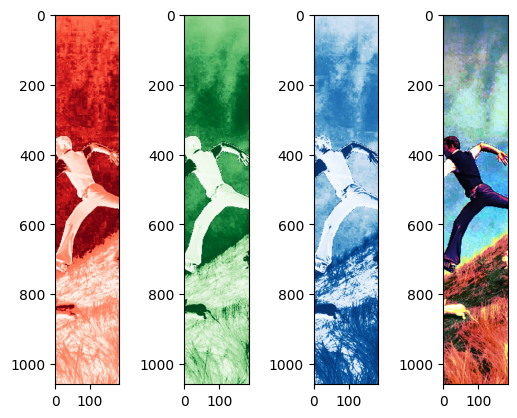

In [ ]:
plt.subplot(1, 4, 1)
er = ekualisasi_histogram (merah)
plt.imshow(er, cmap ="Reds")

plt.subplot(1, 4, 2)
eg = ekualisasi_histogram (hijau)
plt.imshow(eg, cmap ="Greens")

plt.subplot(1, 4, 3)
eb = ekualisasi_histogram (biru)
plt.imshow(eb, cmap ="Blues")


plt.subplot(1, 4, 4)
h,w = tengah.shape
gabungkah = np.zeros((h,w,3), dtype=np.uint8)
gabungkah[:, :, 2] = er
gabungkah[:, :, 1] = eg
gabungkah[:, :, 0] = eb

plt.imshow(gabungkah)

## Histogram Bagian Tengah Setelah Ekualisasi

Histogram dihitung dari gambar `gabungkah` (hasil ekualisasi) dan ditampilkan.

Dibandingkan histogram sebelumnya (sel 16), distribusi intensitas seharusnya terlihat lebih merata dan tersebar di seluruh rentang 0–255 — yang merupakan tanda ekualisasi histogram berhasil.

Text(0, 0.5, 'Jumlah Pixel')

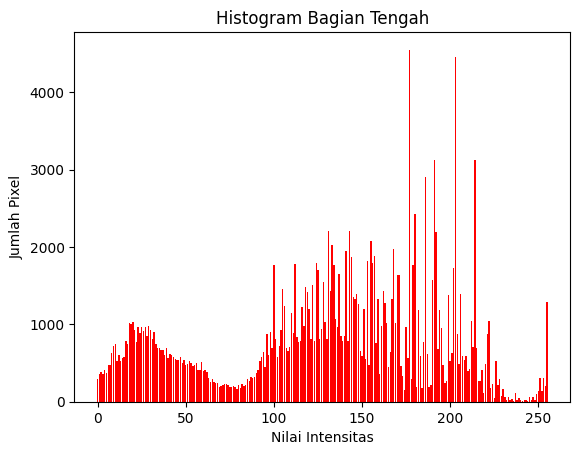

In [ ]:
histogram_gabung = hitung_histogram(gabungkah)
plt.bar(range(256), histogram_gabung, color='red')
plt.title('Histogram Bagian Tengah')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Pixel')

## Fungsi Menggabungkan Citra

Dua fungsi penggabungan gambar secara manual:

**`merge_horizon(citra_1, citra_2)`** — menyambung dua gambar secara **horizontal** (kiri-kanan):
- Lebar hasil = lebar citra_1 + lebar citra_2
- Tinggi mengikuti citra_1

**`merge_vertical(citra_1, citra_2)`** — menyambung dua gambar secara **vertikal** (atas-bawah):
- Tinggi hasil = tinggi citra_1 + tinggi citra_2
- Lebar mengikuti citra_1

Kedua fungsi mendukung gambar grayscale (2D) maupun RGB (3D).

In [ ]:

def merge_horizon(citra_1, citra_2):
    citra_1 = np.array(citra_1)
    citra_2 = np.array(citra_2)

    tinggi = citra_1.shape[0]
    lebar = citra_1.shape[1] + citra_2.shape[1]

    if citra_1.ndim == 3:
        hasil = np.zeros((tinggi, lebar, citra_1.shape[2]), dtype=citra_1.dtype)
    else:
        hasil = np.zeros((tinggi, lebar), dtype=citra_1.dtype)

    hasil[0:citra_1.shape[0], 0:citra_1.shape[1]] = citra_1
    hasil[0:citra_2.shape[0], citra_1.shape[1]:] = citra_2
    return hasil

def merge_vertical(citra_1, citra_2):
    citra_1 = np.array(citra_1)
    citra_2 = np.array(citra_2)

    tinggi = citra_1.shape[0] + citra_2.shape[0]
    lebar = citra_1.shape[1]

    if citra_1.ndim == 3:
        hasil = np.zeros((tinggi, lebar, citra_1.shape[2]), dtype=citra_1.dtype)
    else:
        hasil = np.zeros((tinggi, lebar), dtype=citra_1.dtype)

    hasil[0:citra_1.shape[0], 0:citra_1.shape[1]] = citra_1
    hasil[citra_1.shape[0]:, 0:citra_2.shape[1]] = citra_2
    return hasil



## Hasil Final

Tiga bagian gambar digabung kembali menjadi satu gambar utuh menggunakan `merge_horizon()`:
1. `potong1` (kiri asli) + `gabungkah` (tengah setelah ekualisasi) → `m1`
2. `m1` + `potong3` (kanan asli) → `m2`

**Hasil akhir `m2`** adalah gambar komposit lengkap di mana:
- Bagian **kiri dan kanan** tetap menggunakan piksel asli
- Bagian **tengah** telah diproses dengan ekualisasi histogram untuk meningkatkan kontras

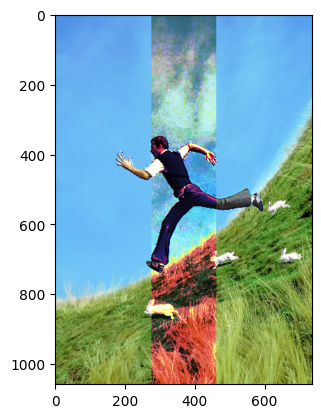

In [ ]:
m1 = merge_horizon(potong1, gabungkah)
m2 = merge_horizon(m1, potong3)

plt.imshow(m2)  # tanpa cmap="gray" karena sudah berwarna

## Histogram Gambar Final

Histogram dihitung dari gambar final `m2` dan ditampilkan sebagai bar chart.

Ini merupakan **evaluasi akhir** dari seluruh pipeline pemrosesan: dimulai dari membaca gambar, memisahkan channel, spesifikasi histogram, compositing foreground-background, pemotongan, ekualisasi, hingga penggabungan kembali menjadi gambar utuh.

Text(0, 0.5, 'Jumlah Pixel')

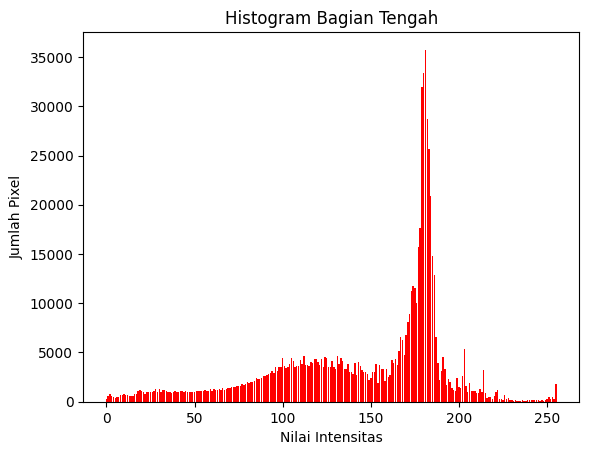

In [ ]:
histogram_gabung_lagi = hitung_histogram(m2)
plt.bar(range(256), histogram_gabung_lagi, color='red')
plt.title('Histogram Bagian Tengah')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Pixel')